Problem 1 done. Final avg occupancy: 0.9875766983271501


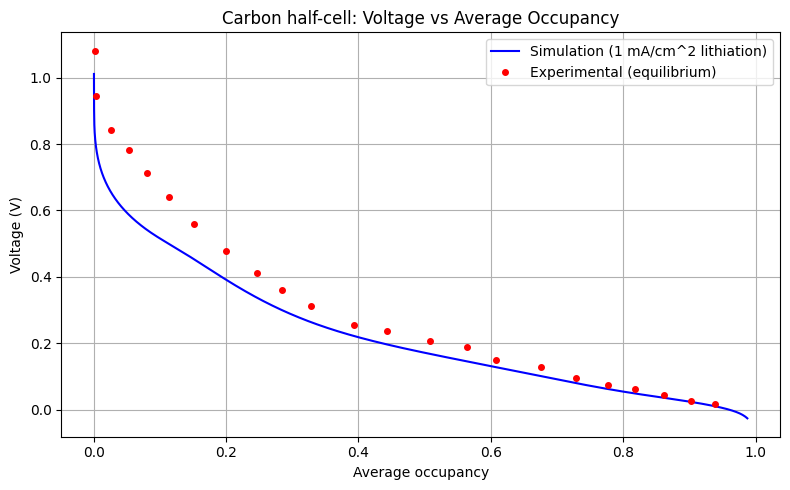

In [ ]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Physical constants
F = 96485               # C/mol
R_gas = 8.314           # J/mol/K
T = 298                 # K
Vth = R_gas * T / F     # RT/F ~ 0.02569 V

# ----------------------------------------------------------------------
# Parameters from Verbrugge & Koch (Tables I and II)
R_p = 3.5e-6             # particle radius (m)
c_max = 18000            # maximum concentration (mol/m^3)
D = 1e-14                # diffusion coefficient at infinite dilution (m^2/s)
i_app = 10.0             # applied current density (A/m^2) = +1 mA/cm^2 (lithiation)
U0 = 0.8170              # standard potential U^s (V)

# A_k = k * Omega_k / F  (in volts) from Table I
A2 = 1.9852
A3 = 2.6943
A4 = -22.52
A5 = 42.975
A6 = -34.704
A7 = 10.276

# B_k = k(k-1) * Omega_k / (R T) = (k-1) * A_k / Vth  (dimensionless)
B2 = (2 - 1) * A2 / Vth
B3 = (3 - 1) * A3 / Vth
B4 = (4 - 1) * A4 / Vth
B5 = (5 - 1) * A5 / Vth
B6 = (6 - 1) * A6 / Vth
B7 = (7 - 1) * A7 / Vth

# ----------------------------------------------------------------------
# Build the PyBaMM model
model = pybamm.BaseModel()

r = pybamm.SpatialVariable("r", domain="particle", coord_sys="spherical")
c = pybamm.Variable("Concentration", domain="particle")

D_param = pybamm.Parameter("Diffusion coefficient")
i_app_param = pybamm.Parameter("Applied current density")
c_max_param = pybamm.Parameter("Maximum concentration")
U0_param = pybamm.Parameter("U^s")
A2_param = pybamm.Parameter("A2")
A3_param = pybamm.Parameter("A3")
A4_param = pybamm.Parameter("A4")
A5_param = pybamm.Parameter("A5")
A6_param = pybamm.Parameter("A6")
A7_param = pybamm.Parameter("A7")
B2_param = pybamm.Parameter("B2")
B3_param = pybamm.Parameter("B3")
B4_param = pybamm.Parameter("B4")
B5_param = pybamm.Parameter("B5")
B6_param = pybamm.Parameter("B6")
B7_param = pybamm.Parameter("B7")

# Thermodynamic (activity-coefficient corrected) effective diffusivity:
# D_eff = D * [ 1/(1-theta) + (1/RT) * sum_k k(k-1) Omega_k theta^(k-1) ]
factor = (1 / (1 - c / c_max_param)
          + B2_param * (c / c_max_param)
          + B3_param * (c / c_max_param) ** 2
          + B4_param * (c / c_max_param) ** 3
          + B5_param * (c / c_max_param) ** 4
          + B6_param * (c / c_max_param) ** 5
          + B7_param * (c / c_max_param) ** 6)

D_eff = D_param * factor
D_eff_surf = pybamm.surf(D_eff)

N = -D_eff * pybamm.grad(c)
dc_dt = -pybamm.div(N)
model.rhs = {c: dc_dt}

# Boundary conditions (see module docstring for sign convention)
dcdr_R = i_app_param / F / D_eff_surf
model.boundary_conditions = {
    c: {
        "left": (pybamm.Scalar(0), "Neumann"),
        "right": (dcdr_R, "Neumann"),
    }
}

c0 = 5e-4 * c_max_param
model.initial_conditions = {c: c0}

c_avg = pybamm.r_average(c)
theta_avg = c_avg / c_max_param
c_surf = pybamm.surf(c)
theta_surf = c_surf / c_max_param

V = (U0_param
     + Vth * pybamm.log((c_max_param - c_surf) / c_surf)
     - (A2_param * (c_surf / c_max_param)
        + A3_param * (c_surf / c_max_param) ** 2
        + A4_param * (c_surf / c_max_param) ** 3
        + A5_param * (c_surf / c_max_param) ** 4
        + A6_param * (c_surf / c_max_param) ** 5
        + A7_param * (c_surf / c_max_param) ** 6))

model.variables = {
    "Average occupancy": theta_avg,
    "Surface occupancy": theta_surf,
    "Voltage": V,
}

geometry = {
    "particle": {
        r: {"min": pybamm.Scalar(0), "max": pybamm.Parameter("Particle radius")}
    }
}

param = pybamm.ParameterValues({
    "Particle radius": R_p,
    "Diffusion coefficient": D,
    "Applied current density": i_app,
    "Maximum concentration": c_max,
    "U^s": U0,
    "A2": A2, "A3": A3, "A4": A4, "A5": A5, "A6": A6, "A7": A7,
    "B2": B2, "B3": B3, "B4": B4, "B5": B5, "B6": B6, "B7": B7,
})

submesh_types = {"particle": pybamm.Uniform1DSubMesh}
spatial_methods = {"particle": pybamm.FiniteVolume()}
n_r = 50
var_pts = {r: n_r}

sim = pybamm.Simulation(
    model,
    geometry=geometry,
    parameter_values=param,
    submesh_types=submesh_types,
    spatial_methods=spatial_methods,
    var_pts=var_pts,
)

t_eval = np.linspace(0, 600, 500)
sol = sim.solve(t_eval=t_eval)

# ----------------------------------------------------------------------
# Experimental data from Table 1
exp_data = np.array([
    [0.0014, 1.0812], [0.0030, 0.9437], [0.0263, 0.8437],
    [0.0538, 0.7811], [0.0802, 0.7114], [0.1144, 0.6418],
    [0.1522, 0.5583], [0.2000, 0.4772], [0.2466, 0.4124],
    [0.2841, 0.3615], [0.3284, 0.3130], [0.3940, 0.2553],
    [0.4425, 0.2371], [0.5080, 0.2075], [0.5644, 0.1893],
    [0.6085, 0.1501], [0.6762, 0.1298], [0.7282, 0.0953],
    [0.7767, 0.0748], [0.8184, 0.0636], [0.8624, 0.0430],
    [0.9019, 0.0270], [0.9380, 0.0181]
])

plt.figure(figsize=(8, 5))
plt.plot(sol["Average occupancy"].entries, sol["Voltage"].entries, 'b-',
         label='Simulation (1 mA/cm^2 lithiation)')
plt.plot(exp_data[:, 0], exp_data[:, 1], 'ro', markersize=4, label='Experimental (equilibrium)')
plt.xlabel('Average occupancy')
plt.ylabel('Voltage (V)')
plt.title('Carbon half-cell: Voltage vs Average Occupancy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('Problem1.png', dpi=150)
print("Problem 1 done. Final avg occupancy:", sol["Average occupancy"].entries[-1])
